In [ ]:
### Installing dependencies

import mesa
from mesa import Model
from mesa.datacollection import DataCollector
from mesa.discrete_space import CellAgent, OrthogonalMooreGrid

### Creating the Agents

class BaseCell(CellAgent):

  """
  The BaseCell class represents any cell in the simulation with the following attributes:
  pos - position of the cell
  health - the health of the cell
  """

  def __init__(self, model, cell, health=1.0):
    super().__init__(model)
    self.cell = cell
    self.health = health

class TumourCell(BaseCell):

  """
  The TumourCell class represents all tumour cells:
  antigen - the level of surface antigen that the ImmuneCell class can recognise (between 0 and 9)
  """

  def __init__(self, model, cell, health=1.0, antigen=1):
    super().__init__(model, cell, health)
    self.antigen = antigen

  def die(self):
    """Removes the cell from the model's schedule and the grid."""
    self.remove()

  def step(self):
    pass

class ImmuneCell(BaseCell):

  """
  An ImmuneCell class that represents cells of the immune system with the ability to kill TumourCell agents
  """

  def __init__(self, model, cell, health=1.0):
    super().__init__(model, cell, health)


  def move(self):
    #Move the immune cell to a random neighboring cell
    self.cell = self.cell.neighborhood.select_random_cell()

  def kill(self):
    #Kill a TumourCell agent if they share the same position in the grid and have antigen=1
    cellmates = [a for a in self.cell.agents if a is not self]

    if cellmates:
      # Filter for TumourCell agents with antigen=1
      target_tumour_cells = [a for a in cellmates if isinstance(a, TumourCell) and a.antigen == 1]

      if target_tumour_cells:
        # Select one target randomly and decrease its health
        target = self.random.choice(target_tumour_cells)
        target.health -= 1
        # If the target's health drops to 0 or below, the tumour cell dies
        if target.health <= 0:
          target.die()

  def step(self):
    """
    Execute one step for the agent:
    1. Move to a neighbouring cell
    2. If cell is occupied by a TumourCell, then kill the cell
    """

    self.move()
    self.kill()

Cannot show ipywidgets in text

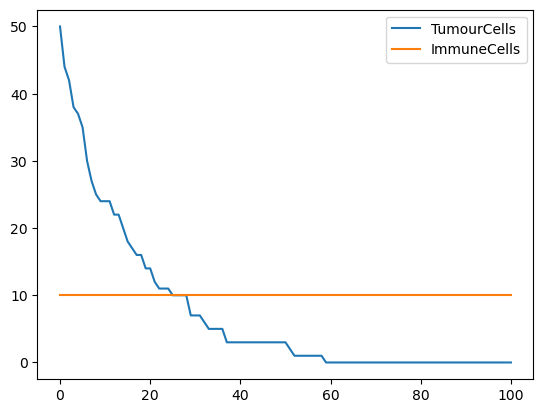

In [2]:
class EvasionModel(Model):
  def __init__(self, n_tumour=30, n_immune=10, width=10, height=10):
    super().__init__()

    #Create the grid
    self.grid = OrthogonalMooreGrid(
        (width, height), torus=True, random=self.random
    )

    #Place tumour cells on random empty cells
    for _ in range(n_tumour):
      cell = self.grid.all_cells.select_random_cell()
      TumourCell(self, cell)

    #Place immune cells on random empty cells
    for _ in range(n_immune):
      cell = self.grid.all_cells.select_random_cell()
      ImmuneCell(self, cell)

    #Verify placement
    for agent in self.agents:
      assert agent.cell is not None, f'Agent {agent.unique_id} has no cell'

    #Data Collection
    self.datacollector = DataCollector(
        model_reporters={
            "TumourCells": lambda m: len(m.agents_by_type[TumourCell]),
            "ImmuneCells": lambda m: len(m.agents_by_type[ImmuneCell]),
        },
    )
    self.datacollector.collect(self)

  def step(self):
    self.agents.shuffle_do('step')
    self.datacollector.collect(self)



"""
Run the model and plot
"""

model = EvasionModel(n_tumour=50, n_immune=10, width=10, height=10)

for _ in range(100):
  model.step()

df = model.datacollector.get_model_vars_dataframe()
df.plot()

from mesa.visualization import SolaraViz, SpaceRenderer, make_plot_component
from mesa.visualization.components import AgentPortrayalStyle


def agent_portrayal(agent):
    if isinstance(agent, TumourCell):
        # Red for tumour, slightly bigger so they read as the "target"
        return AgentPortrayalStyle(color="tab:red", size=40)
    elif isinstance(agent, ImmuneCell):
        return AgentPortrayalStyle(color="tab:blue", size=40)


model_params = {
    "n_tumour": {
        "type": "SliderInt",
        "value": 30,
        "label": "Number of tumour cells:",
        "min": 10,
        "max": 50,
        "step": 1,
    },
    "n_immune": {
        "type": "SliderInt",
        "value": 10,
        "label": "Number of immune cells:",
        "min": 1,
        "max": 25,
        "step": 1,
    },
    "width": 10,
    "height": 10,
}

# Create initial model instance
evasion_model = EvasionModel(n_tumour=30, n_immune=10, width=10, height=10)

# Set up the space renderer
renderer = (
    SpaceRenderer(model=evasion_model, backend="matplotlib")
    .setup_agents(agent_portrayal)
    .render()
)

# Time series plot of the two populations — put on page 1 so the grid has page 0 to itself
PopulationPlot = make_plot_component(
    {"TumourCells": "tab:red", "ImmuneCells": "tab:blue"},
    page=1,
)

page = SolaraViz(
    evasion_model,
    renderer,
    components=[PopulationPlot],
    model_params=model_params,
    name="Tumour-Immune Evasion Model",
)
page